<a href="https://colab.research.google.com/github/gvp2ms/A03-knn/blob/main/a03_knn_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Tiffany Kim

**Date:** 10/02/2026

In [3]:
# Your Phase 1 solution to the problem goes here.


**What is the difference between regression and classification?**

Regression predicts continuous numerical values or outputs, while classification predicts discrete values or categories.

**What is a confusion table? What does it help us understand about a model's performance?**

A confusion table helps visualize the performance on a specific task of a person or algorithm. Each column represents predicted instances, while the rows reprensent actual instances. It helps understand a model's performance by breaking the instances of errors down into specific types, so you can see where a model fails and why it fails at a task, instead of generalizing the number of errors there were.

**What does the SSE quantify about a particular model?**

SSE is the Sum of Squared Errors, which quantifies the total error in a regression model, so it measures the discrepencies betwen the data and a particular model.

**What are overfitting and underfitting?**

Underfitting is when a model is too simple to capture the underlying patterns in the data. Overfitting is when a model not only captures the underlying patterns but also extraneous things like noise or random quirks. Both can cause the model to perform badly; underfitting performs badly on training data, and overfitting has high accuracy on training data but fails on validation.

**Why does splitting the data into training and testing sets, and choosing  k  by evaluating accuracy or SSE on the test set, improve model performance?**

Splitting the data into training and testing sets improves model performance by measuring generalization. The training sets learn the patterns by using a general amount of the data, while the testing sets evaluates how the learned model handles new, smaller, more specific sections of data. It also prevents the model from "memorizing" the data and makes it actually learn. Choosing k by evaluating accurancy or SSE on the test set also helps overfitting. Too small of a k means the model is overfitting, while too big of a k means the model is underfitting.

**With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**

Reporting a class label as a prediction means each input is classified as one specific category of output. This can be helpful because it is direct, simplistic, and requires lower storage and computing power. However, it can result in loss of information because the model has no uncertainty, and it can lead to false positives and negatives.

Reporting a probability distribution over class labels means a likelihood score is assigned to all possible classes, so that all the classes add up to 1. This helps reveal how sure a model is, the decision threshold can be changed, and allows you to combine predictions from multiple models. However, it is more complex to implement and can be less intuitive.

In [4]:
#Phase 1 Coding
import pandas as pd
import numpy as np

#1. Load the data. Perform some EDA, summarizing the target label and the features.
df = pd.read_csv('land_mines.csv')
print(df.columns)
print(df.isnull().sum())
print(df.describe())
#target label is mine type
print(df.mine_type.value_counts())
print(df.mine_type.value_counts(normalize=True))


Index(['voltage', 'height', 'soil', 'mine_type'], dtype='object')
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64


In [5]:
#2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
x = df.drop(columns=['mine_type'])
y = df.mine_type
print(x.shape)
print(y.shape)
print(y.value_counts())
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42, stratify=y)
print("Training:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
print("Testing:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

#need to standardize variables ranges so that certain variables don't dominate the distance calculation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)


(338, 3)
(338,)
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
Training:
mine_type
1    35
2    35
3    33
5    33
4    33
Name: count, dtype: int64
mine_type
1    0.207101
2    0.207101
3    0.195266
5    0.195266
4    0.195266
Name: proportion, dtype: float64
Testing:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64
mine_type
1    0.213018
2    0.207101
3    0.195266
4    0.195266
5    0.189349
Name: proportion, dtype: float64


In [6]:
#3 Build a  k -NN classifier. Explain how you select  k
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print(y_pred)
print(y_test.values)

from sklearn.model_selection import cross_val_score
k_values = range(1, 21)
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print("Optimal k:", optimal_k)

knn_final = KNeighborsClassifier(n_neighbors=optimal_k)

knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

#I chose my K as 6 by finding the value that had the highest cross-validation accuracy
#The cv_scores were my cross-validation so I chose the highest value of that list
#A k too small could make the model too sensitive to individual observations, causing overfitting
#A k too large could result in underfit and ignore meaningful data
#So, a k of 6 was the best choice


[1 4 3 1 1 5 3 1 4 2 2 5 3 4 4 1 2 5 2 1 3 2 4 2 1 2 3 3 1 1 4 2 1 2 2 5 3
 1 2 1 4 1 1 1 4 1 2 2 1 4 2 1 1 1 1 1 4 3 5 4 5 3 4 1 2 4 2 4 1 4 2 3 2 5
 3 2 4 5 1 4 4 3 1 3 1 4 1 3 1 1 2 5 2 2 2 2 1 3 2 1 2 1 5 1 5 2 3 4 2 1 1
 1 2 3 5 3 4 2 4 3 2 1 2 3 5 5 1 5 2 2 1 1 4 3 1 1 3 3 4 4 1 4 5 4 1 1 3 1
 2 2 3 5 4 1 1 5 5 4 1 2 1 1 3 1 2 2 2 1 3]
[3 1 4 4 3 3 4 4 2 4 2 5 1 3 5 4 2 5 2 1 1 2 3 2 1 2 5 3 4 1 5 2 1 2 2 3 4
 1 2 5 5 1 4 3 4 1 2 2 1 1 3 3 5 4 1 1 5 1 2 3 3 3 3 1 2 5 2 5 5 4 2 1 2 4
 5 2 4 5 1 4 3 5 5 5 1 5 3 5 1 1 4 5 2 4 2 2 4 5 2 5 3 4 1 4 4 2 1 3 2 5 3
 1 2 1 3 4 4 2 5 3 2 1 2 4 3 3 4 3 2 4 1 1 5 5 1 1 4 5 2 3 1 3 3 5 1 4 3 4
 2 4 4 4 5 3 1 3 3 1 4 2 3 1 5 1 2 2 3 5 5]
Optimal k: 6


Confusion Matrix:
[[23  0  7  5  1]
 [ 0 34  0  1  0]
 [ 9  3  5  6 10]
 [15  5  7  3  3]
 [ 9  2 10  6  5]]


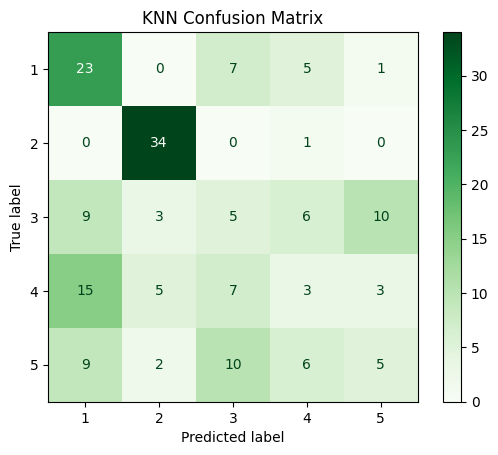

Test-set accuracy: 0.41420118343195267

Classification report:
              precision    recall  f1-score   support

           1       0.41      0.64      0.50        36
           2       0.77      0.97      0.86        35
           3       0.17      0.15      0.16        33
           4       0.14      0.09      0.11        33
           5       0.26      0.16      0.20        32

    accuracy                           0.41       169
   macro avg       0.35      0.40      0.37       169
weighted avg       0.36      0.41      0.38       169


Based on the classification report, the model has 41% overall accuracy
Mine type 2 is where the model performed the best, with a precision of 77% and a recall of 91%.
Mine types 3, 4, and 5 are where the model performed poorly. The precision is between 14-26% and the recall is between 9-16%.


In [7]:
#4 Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred,labels=[1, 2, 3, 4, 5])
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])

disp.plot(cmap="Greens")
plt.title("KNN Confusion Matrix")
plt.show()

from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Test-set accuracy:", accuracy)
print("\nClassification report:")
print(classification_report(y_test, y_pred, labels=[1, 2, 3, 4, 5],zero_division=0))
print()
print("Based on the classification report, the model has 41% overall accuracy")
print("Mine type 2 is where the model performed the best, with a precision of 77% and a recall of 91%.")
print("Mine types 3, 4, and 5 are where the model performed poorly. The precision is between 14-26% and the recall is between 9-16%.")


**Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.**

I would not advise the use of a K-NN model as an autonomous system to decide if a suspected landmine is safe or not. Instead, the predictions drawn from the model can be assessed by a human as a preliminary screening or decision making tool. The overall accuracy of the model is misleading because it can only precisely detect one type of mine. This model can be used to give an initial view of types of mines, but specific detection of mines should be consulted by a human.



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

[link text](https://)- **Phase 1 commit SHA ID:** 51d78e6e1f70e005e40e777cc0cc361e42d3dd4a
- **AI tool and model used:** Gemini 3


### *Prompts used

1. Is this enough to properly summarize the target label and features? What more could I add?
2. Can you clean up my confusion matrix? I think there is a lot of unnecessary information and there is most likely a better way to structure it. However, don't touch my print statements at the bottom as that is my explanations to the question.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. While your code provides a good starting point, it misses a few critical aspects of exploratory data analysis (EDA). To perform a thorough EDA, you should also examine data types, shape, distributions, feature relationships, and skewness/outliers.

Here is what is currently missing and how to expand your script:

What to Add
Dataset Overview: Shape, data types, and non-null counts (df.info()).

Feature Distributions & Skewness: Checking standard deviation, skewness, min/max, and quantiles to see if normalization or scaling is required (especially useful for land mine sensor data like voltage, magnetic response, or soil properties).

Correlation Analysis: Seeing how features correlate with each other and with the target label to identify multicollinearity or key predictive features.

Visual Explorations: Histograms, boxplots, and scatter/pair plots to detect outliers and feature separation across mine types.

2. Key Enhancements Made
Formatted Terminal Printout: Wrapped cm into a pandas.DataFrame labeled with Actual and Pred row/column headers so the printed array is easy to read.

Plot Grid & Size Control: Added ax.grid(False) to eliminate gridline artifacts slicing through the matrix cells and specified a figsize=(6, 5) for proportions.

Axis Labels & Typography: Explicitly added labeled axes (Predicted Mine Type vs. Actual Mine Type) and adjusted padding and font weights.

Integer Values: Added values_format="d" to guarantee whole numbers inside the heatmap cells without scientific notation.

Consolidated Imports: Consolidated all imports at the top of the block for cleaner script organization.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | My initial EDA was very basic and did not really provide in-depth investigations. The AI's code was a lot more thorough and provided a better overall EDA. The AI also added a visualization of my data to make it clearer to read. |
| 2 | Accept | I think the AI did a good job of cleaning up my confusion matrix, as I used a lot more code before to create it. The AI helped find more concise code to use and also helped me organize my code. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [9]:
# Your Phase 2 solution to the problem goes here.


=== Shape & Structure ===
Shape: (338, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None

=== Missing Values ===
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

=== Target Class Distribution ===
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

=== Target Class Percentages ===
mine_type
1    21.01
2    20.71
3    19.53
4    19.53
5    19.23
Name: proportion, dtype: float64

=== Detailed Feature Summary ===
               mean       std       min       50%       max      skew
voltage    0.430634  0.195819  0.197734  0.359516  0.999999  1.726371
height     0.508876  0.306043  0.000000  0.5

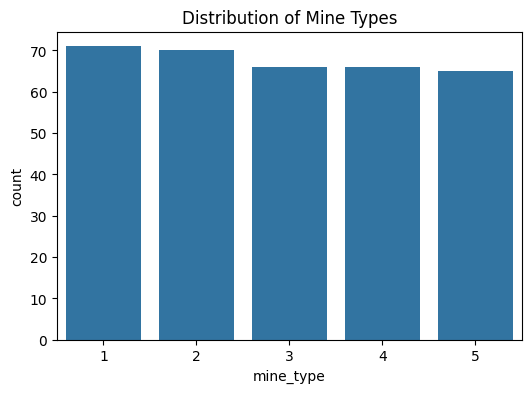

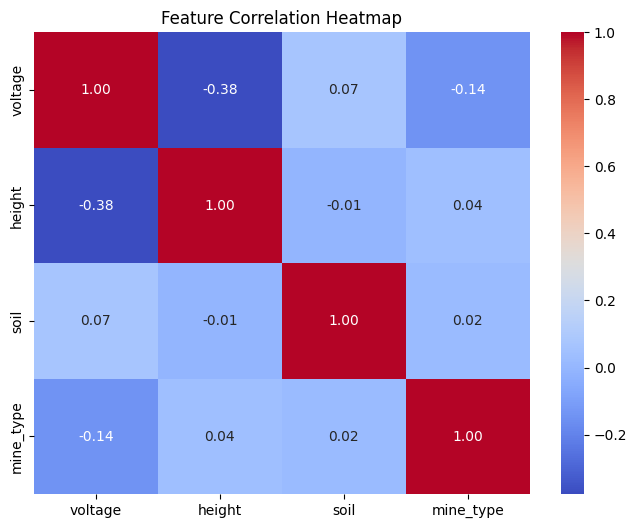

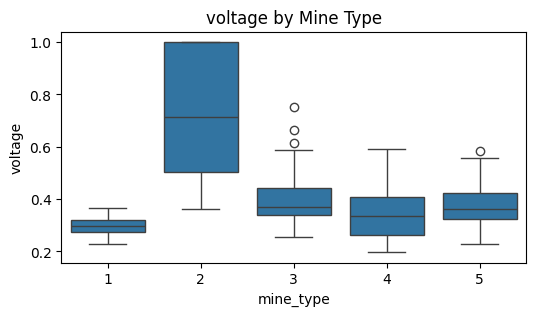

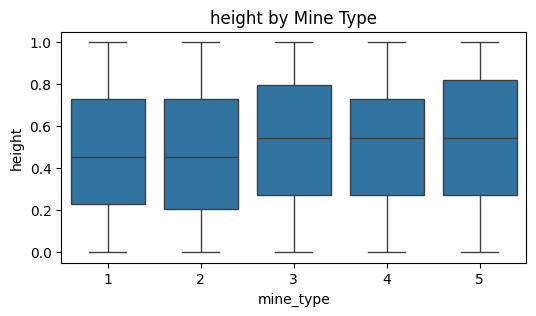

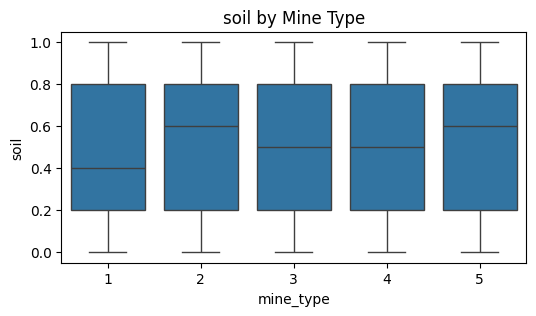

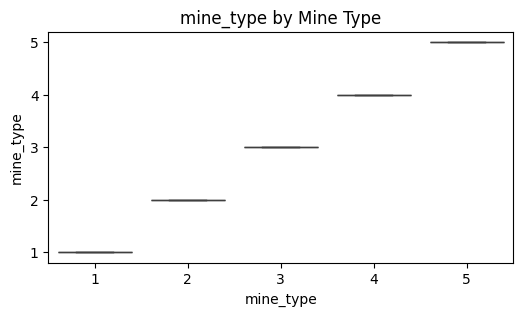

In [11]:
#1
import pandas as pd
import numpy as np

# 1. Load Data
df = pd.read_csv('land_mines.csv')

# 2. Dataset Overview
print("=== Shape & Structure ===")
print(f"Shape: {df.shape}")
print(df.info())

# 3. Missing Values Check
print("\n=== Missing Values ===")
print(df.isnull().sum())

# 4. Target Label Summary
print("\n=== Target Class Distribution ===")
print(df['mine_type'].value_counts())
print("\n=== Target Class Percentages ===")
print(df['mine_type'].value_counts(normalize=True).round(4) * 100)

# 5. Feature Numerical Summary (Extended)
print("\n=== Detailed Feature Summary ===")
# Transposing .describe() makes it much easier to read when you have many features
summary = df.describe().T
summary['skew'] = df.skew(numeric_only=True)  # Check for high skewness
print(summary[['mean', 'std', 'min', '50%', 'max', 'skew']])

# 6. Grouped Summary (Features by Target Class)
print("\n=== Feature Means by Mine Type ===")
print(df.groupby('mine_type').mean())

# 7. Feature Correlation Matrix
print("\n=== Feature Correlation Matrix ===")
print(df.corr(numeric_only=True).round(2))

import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Target Class
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='mine_type')
plt.title('Distribution of Mine Types')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

# Feature Distributions per Class (Boxplots for Outlier Detection)
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=df, x='mine_type', y=col)
    plt.title(f'{col} by Mine Type')
    plt.show()

In [ ]:
#2
x = df.drop(columns=['mine_type'])
y = df.mine_type
print(x.shape)
print(y.shape)
print(y.value_counts())
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42, stratify=y)
print("Training:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))
print("Testing:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

#need to standardize variables ranges so that certain variables don't dominate the distance calculation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [ ]:
#3
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print(y_pred)
print(y_test.values)

from sklearn.model_selection import cross_val_score
k_values = range(1, 21)
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print("Optimal k:", optimal_k)

knn_final = KNeighborsClassifier(n_neighbors=optimal_k)

knn_final.fit(X_train_scaled, y_train)

y_pred = knn_final.predict(X_test_scaled)

#I chose my K as 6 by finding the value that had the highest cross-validation accuracy
#The cv_scores were my cross-validation so I chose the highest value of that list
#A k too small could make the model too sensitive to individual observations, causing overfitting
#A k too large could result in underfit and ignore meaningful data
#So, a k of 6 was the best choice

Confusion Matrix:
          Pred 1  Pred 2  Pred 3  Pred 4  Pred 5
Actual 1      23       0       7       5       1
Actual 2       0      34       0       1       0
Actual 3       9       3       5       6      10
Actual 4      15       5       7       3       3
Actual 5       9       2      10       6       5



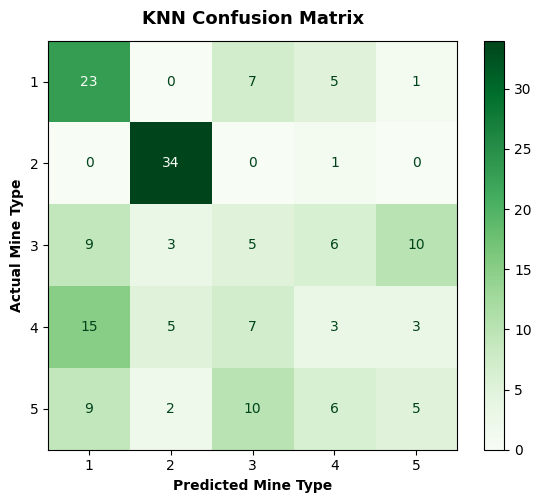

Test-set accuracy: 0.4142

Classification report:
              precision    recall  f1-score   support

           1       0.41      0.64      0.50        36
           2       0.77      0.97      0.86        35
           3       0.17      0.15      0.16        33
           4       0.14      0.09      0.11        33
           5       0.26      0.16      0.20        32

    accuracy                           0.41       169
   macro avg       0.35      0.40      0.37       169
weighted avg       0.36      0.41      0.38       169


Based on the classification report, the model has 41% overall accuracy
Mine type 2 is where the model performed the best, with a precision of 77% and a recall of 91%.
Mine types 3, 4, and 5 are where the model performed poorly. The precision is between 14-26% and the recall is between 9-16%.


In [12]:
#4
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Class labels
labels = [1, 2, 3, 4, 5]

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

# 1. Print Labeled Table Output
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {i}" for i in labels],
    columns=[f"Pred {i}" for i in labels]
)
print("Confusion Matrix:")
print(cm_df)
print()

# 2. Clean Confusion Matrix Plot
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Greens", ax=ax, values_format="d", colorbar=True)

# Visual improvements
ax.set_title("KNN Confusion Matrix", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Mine Type", fontsize=10, fontweight="bold")
ax.set_ylabel("Actual Mine Type", fontsize=10, fontweight="bold")
ax.grid(False)  # Removes grid lines from interfering with matrix cells
plt.tight_layout()
plt.show()

# 3. Model Accuracy & Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Test-set accuracy: {accuracy:.4f}\n")

print("Classification report:")
print(classification_report(y_test, y_pred, labels=labels, zero_division=0))
print()

# 4. Text Analysis
print("Based on the classification report, the model has 41% overall accuracy")
print("Mine type 2 is where the model performed the best, with a precision of 77% and a recall of 91%.")
print("Mine types 3, 4, and 5 are where the model performed poorly. The precision is between 14-26% and the recall is between 9-16%.")

**Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.**

I would not advise the use of a K-NN model as an autonomous system to decide if a suspected landmine is safe or not. Instead, the predictions drawn from the model can be assessed by a human as a preliminary screening or decision making tool. The overall accuracy of the model is misleading because it can only precisely detect one type of mine. This model can be used to give an initial view of types of mines, but specific detection of mines should be consulted by a human.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

As the course material gets progressively more in-depth and specific about methods of data analysis and machine learning, I have found that my prior knowledge of Python, Pandas, and NumPy are lacking and I need to know a lot more specific functions to complete the assignments. While searching for these functions online helps, AI is a lot better at finding and implementing specific functions that do the tasks much more efficiently and simplistically. AI is also really good at organizing the code that I write, making it easier to look at and understand what I wrote. The AI is also really helpful in generating visual data, like graphs and charts. Especially for this assignment, it helped to see where the model that I built was lacking in precision and accuracy when determining types of landmines and the safety of them.